# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from cross_sections import *
%matplotlib inline
pd.set_option('display.max_rows', None)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2020\PSI20_01NI\01_Transmission\HE"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [3]:
# %load select_file('spectra_file')
spectra_file = r"H:\700 Campaigns - internal\780 2020\PSI20_01NI\temp\exps_HE\IMAT_HE_Spectra.txt"

#### Provide the directory for saving results

In [4]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2020\PSI20_01NI\02_CS_results"

In [5]:
flight_path = 56

## Remove Casing 
read the directory and extract values from images

In [6]:
casing_dict = read_saved_dict (src_dir, proc_folder = ['05_p3'])
stack_dict = read_saved_dict (src_dir, proc_folder = ['05_p3'])

Reading Images: 100%|████████████████████████████| 1/1 [00:12<00:00, 12.99s/it]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in casing_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 40, end_slice = 50)
    avg_imgs.append(img[0])

#### Select the Casing ROI
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
ROIs_05_p3  = [[225, 165, 204, 48]]

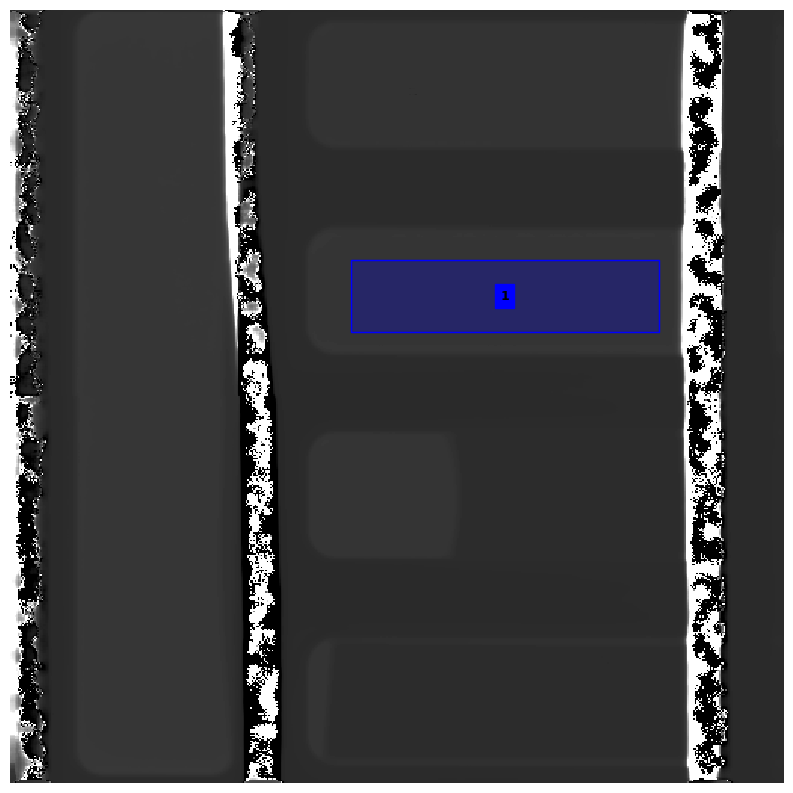

In [9]:
show_img(avg_imgs[0], dr = [(ROIs_05_p3, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [10]:
rois_dict = {}
for name in casing_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

In [11]:
val_casing = get_roi_values (casing_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 5, 
                                 flight_path = flight_path, start_slice = 1, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [12]:
val_casing

,Wavelength [Å],Values_acq_0
0,0.787454,0.933217
1,0.845325,0.934599
2,0.903196,0.935219
3,0.961068,0.932627
4,1.018939,0.930894
5,1.076810,0.929785
6,1.134681,0.926982
7,1.192552,0.927761
8,1.250423,0.926449
9,1.308294,0.928855


## Process a single  experiment

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [13]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
ROIs_01_p1  = [[229, 437, 196, 49]] #PE
#ROIs_01_p1  = [[317, 301, 111, 49]] #H20

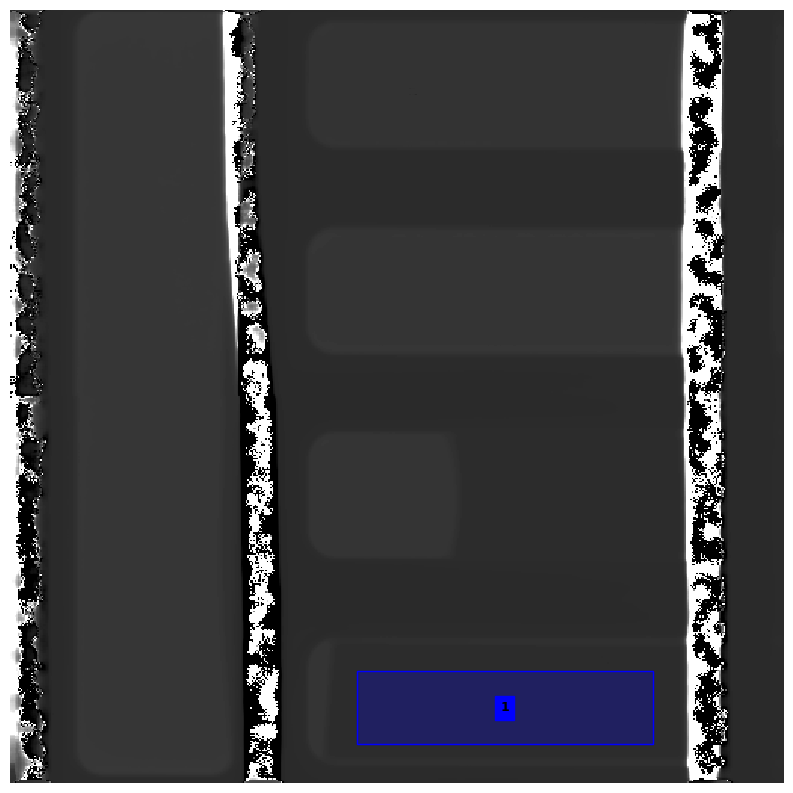

In [14]:
show_img(avg_imgs[0], dr = [(ROIs_01_p1, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [15]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [16]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 5, 
                                 flight_path = flight_path, start_slice = 1, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [17]:
#val_rois = table_val_rois.loc[3:76, :]
#val_rois = table_val_rois.reset_index(drop=True)

val_rois

,Wavelength [Å],Values_acq_0,Values_acq_1,Values_acq_2,Values_acq_3,Values_acq_4,Values_acq_5,Values_acq_6,Values_acq_7,Values_acq_8,...,Values_acq_26,Values_acq_27,Values_acq_28,Values_acq_29,Values_acq_30,Values_acq_31,Values_acq_32,Values_acq_33,Values_acq_34,Values_acq_35
0,0.787454,0.560408,0.563786,0.582843,0.564342,0.574264,0.563105,0.572739,0.549868,0.558177,...,0.583508,0.563969,0.569098,0.563490,0.592439,0.589535,0.582023,0.561875,0.549980,0.545320
1,0.845325,0.589062,0.583707,0.581827,0.570664,0.573274,0.572191,0.578796,0.575401,0.571449,...,0.588490,0.595132,0.581901,0.586463,0.587570,0.588734,0.584602,0.589512,0.593019,0.581177
2,0.903196,0.567927,0.567756,0.567054,0.562837,0.565368,0.563046,0.571656,0.563610,0.564600,...,0.578147,0.576533,0.577858,0.577084,0.578199,0.575716,0.576464,0.578969,0.570675,0.575355
3,0.961068,0.552305,0.552503,0.549182,0.544730,0.553129,0.547691,0.549749,0.551622,0.547371,...,0.559064,0.562330,0.568395,0.563320,0.566284,0.565461,0.559105,0.560444,0.557000,0.554684
4,1.018939,0.538651,0.531840,0.542082,0.537234,0.536623,0.539693,0.538291,0.538473,0.537005,...,0.543157,0.550091,0.543774,0.546754,0.545470,0.545901,0.548932,0.541332,0.536752,0.550230
5,1.076810,0.524058,0.527470,0.524621,0.518838,0.523481,0.524627,0.523543,0.522116,0.519156,...,0.535800,0.530535,0.529684,0.536821,0.534678,0.531139,0.531536,0.534534,0.529045,0.536013
6,1.134681,0.511983,0.511913,0.512601,0.510507,0.509201,0.504497,0.508924,0.508133,0.514283,...,0.518140,0.521949,0.518924,0.517792,0.518288,0.519009,0.514959,0.516322,0.517655,0.517698
7,1.192552,0.496635,0.502775,0.497604,0.500392,0.497885,0.501749,0.504633,0.496457,0.499800,...,0.511368,0.509399,0.507430,0.509130,0.504493,0.510543,0.504870,0.509570,0.507515,0.508563
8,1.250423,0.489175,0.491434,0.487313,0.491387,0.496175,0.491432,0.495558,0.489877,0.487401,...,0.501085,0.498731,0.497363,0.497111,0.503112,0.498893,0.500395,0.505233,0.502298,0.499029
9,1.308294,0.481017,0.481707,0.482836,0.486247,0.483699,0.481832,0.480796,0.478080,0.479509,...,0.494785,0.489867,0.489699,0.487206,0.493281,0.492178,0.490908,0.491169,0.489617,0.489467


### Remove the casing


In [18]:
trans_rois = divide_DF (val_rois, val_casing)

In [19]:
trans_rois

,Wavelength [Å],Values_acq_0,Values_acq_1,Values_acq_2,Values_acq_3,Values_acq_4,Values_acq_5,Values_acq_6,Values_acq_7,Values_acq_8,...,Values_acq_26,Values_acq_27,Values_acq_28,Values_acq_29,Values_acq_30,Values_acq_31,Values_acq_32,Values_acq_33,Values_acq_34,Values_acq_35
0,0.787454,0.600512,0.604131,0.624553,0.604727,0.615360,0.603402,0.613726,0.589218,0.598121,...,0.625265,0.604328,0.609823,0.603815,0.634835,0.631723,0.623674,0.602084,0.589338,0.584345
1,0.845325,0.630283,0.624554,0.622542,0.610598,0.613390,0.612232,0.619299,0.615667,0.611437,...,0.629671,0.636777,0.622621,0.627502,0.628686,0.629932,0.625510,0.630765,0.634517,0.621846
2,0.903196,0.607266,0.607083,0.606333,0.601824,0.604530,0.602047,0.611253,0.602650,0.603709,...,0.618194,0.616468,0.617885,0.617057,0.618249,0.615594,0.616394,0.619073,0.610205,0.615208
3,0.961068,0.592204,0.592416,0.588855,0.584082,0.593087,0.587257,0.589463,0.591471,0.586914,...,0.599451,0.602953,0.609456,0.604015,0.607193,0.606310,0.599495,0.600930,0.597237,0.594754
4,1.018939,0.578638,0.571321,0.582324,0.577116,0.576459,0.579757,0.578251,0.578447,0.576870,...,0.583479,0.590927,0.584142,0.587343,0.585963,0.586426,0.589682,0.581519,0.576598,0.591077
5,1.076810,0.563634,0.567304,0.564239,0.558019,0.563013,0.564246,0.563080,0.561544,0.558361,...,0.576263,0.570600,0.569684,0.577361,0.575055,0.571250,0.571677,0.574901,0.568997,0.576491
6,1.134681,0.552312,0.552237,0.552979,0.550719,0.549310,0.544237,0.549012,0.548158,0.554793,...,0.558953,0.563063,0.559800,0.558579,0.559113,0.559892,0.555522,0.556992,0.558430,0.558477
7,1.192552,0.535304,0.541923,0.536350,0.539354,0.536652,0.540817,0.543925,0.535113,0.538717,...,0.551185,0.549062,0.546941,0.548773,0.543775,0.550296,0.544181,0.549247,0.547032,0.548162
8,1.250423,0.528011,0.530449,0.526002,0.530399,0.535566,0.530447,0.534900,0.528769,0.526096,...,0.540866,0.538325,0.536849,0.536577,0.543054,0.538500,0.540122,0.545344,0.542175,0.538647
9,1.308294,0.517860,0.518603,0.519819,0.523490,0.520748,0.518737,0.517622,0.514698,0.516236,...,0.532683,0.527388,0.527207,0.524523,0.531063,0.529876,0.528509,0.528790,0.527119,0.526957


### H cross section parameters

In [25]:
thickness = 0.3
h2o = {'abbv': 'H2O','composition' : {'H':2.0, 'O':1.0},'density':0.997, 'thickness': thickness}
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dmc_11w = {'abbv': 'EC_DMC (1:1w)','molecules' : [ec,0.447511501,dmc,0.552488499], 'density':1.2335, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#ec_dec_37w = {'abbv': 'EC_DEC (3:7w)','molecules' : [ec,0.240305619,dec,0.759694381], 'density':1.0705, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}
lp47 = {'abbv': 'LP47','molecules' : [ec, 0.218207723,dec, 0.689834809, lipf6 ,0.091957467], 'density':1.1685, 'thickness': thickness}
#ec_dec_sol = {'abbv': 'EC_DEC (sol)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
pe = {'abbv': 'PE', 'composition' : {'C':1.0, 'H':2.0},'density':0.92, 'thickness': 0.21}

## exp1000 -> LP30


In [26]:
compounds_dict = [pe,pe,pe,pe,pe,pe,pe,pe,pe,pe,
                  pe,pe,pe,pe,pe,pe,pe,pe,pe,pe,
                  pe,pe,pe,pe,pe,pe,pe,pe,pe,pe,
                  pe,pe,pe,pe,pe,pe]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [29]:
requested_cs = ['h_cs']
cs_table = get_cross_sections (trans_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = True, 
                               name_xlsx = 'test_HE.xlsx')

In [30]:
cs_table

,Wavelength [Å],CS_H_in_PE_Values_acq_0,CS_H_in_PE_Values_acq_1,CS_H_in_PE_Values_acq_2,CS_H_in_PE_Values_acq_3,CS_H_in_PE_Values_acq_4,CS_H_in_PE_Values_acq_5,CS_H_in_PE_Values_acq_6,CS_H_in_PE_Values_acq_7,CS_H_in_PE_Values_acq_8,...,CS_H_in_PE_Values_acq_26,CS_H_in_PE_Values_acq_27,CS_H_in_PE_Values_acq_28,CS_H_in_PE_Values_acq_29,CS_H_in_PE_Values_acq_30,CS_H_in_PE_Values_acq_31,CS_H_in_PE_Values_acq_32,CS_H_in_PE_Values_acq_33,CS_H_in_PE_Values_acq_34,CS_H_in_PE_Values_acq_35
0,0.787454,28.351137,27.988950,25.984993,27.929511,26.878853,28.061790,27.039171,29.495629,28.591660,...,25.916287,27.969371,27.423653,28.020523,25.000669,25.296917,26.069909,28.193576,29.483402,29.996292
1,0.845325,25.431502,25.981960,26.176470,27.344177,27.069196,27.183122,26.491295,26.845870,27.261378,...,25.490056,24.813575,26.168770,25.698061,25.584435,25.465063,25.889687,25.385466,25.027976,26.243819
2,0.903196,27.670821,27.689025,27.763534,28.213485,27.943077,28.191098,27.276338,28.130804,28.024989,...,26.595731,26.764266,26.625903,26.706671,26.590364,26.849773,26.771478,26.510093,27.379853,26.887581
3,0.961068,29.181435,29.159845,29.523292,30.013881,29.091554,29.687105,29.461055,29.256020,29.722303,...,28.448265,28.097099,27.450467,27.991064,27.674731,27.762444,28.443837,28.299659,28.671229,28.922381
4,1.018939,30.574746,31.341787,30.191996,30.733498,30.802116,30.458219,30.615050,30.594600,30.759156,...,30.072539,29.307914,30.004061,29.674628,29.816439,29.768797,29.435016,30.275389,30.787603,29.292661
5,1.076810,32.154589,31.763368,32.089860,32.758090,32.221003,32.089198,32.213830,32.378455,32.721141,...,30.818865,31.414171,31.510992,30.704128,30.945312,31.345552,31.300491,30.961516,31.583676,30.794990
6,1.134681,33.373770,33.381961,33.301034,33.547857,33.702248,34.261605,33.735013,33.828786,33.103583,...,32.653244,32.211679,32.561994,32.693635,32.636017,32.552150,33.024380,32.865104,32.709697,32.704591
7,1.192552,35.254930,34.514160,35.137342,34.800613,35.103349,34.637299,34.291886,35.276504,34.871912,...,33.492694,33.725285,33.958620,33.757078,34.308527,33.589982,34.263575,33.705024,33.948579,33.824222
8,1.250423,36.077450,35.799772,36.307285,35.805463,35.221039,35.799969,35.296026,35.990973,36.296430,...,34.627441,34.911269,35.076808,35.107358,34.384080,34.891726,34.710432,34.130449,34.481704,34.875256
9,1.308294,37.243012,37.156555,37.015388,36.591144,36.907745,37.140928,37.270689,37.612156,37.432246,...,35.541843,36.143947,36.164624,36.472370,35.725371,35.860273,36.015982,35.983948,36.174747,36.193230


In [ ]:
cs_ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI"
cs_ref_data = pd.read_csv (cs_ref_dir + '\cs_ref_IMAT20.txt',sep='\t')
cs_ref_data = cs_ref_data.loc[0:93, ['orig wvl','orig cs LP30', 'orig cs PE']]
cs_ref_data = cs_ref_data.reset_index(drop=True)
cs_ref_data

In [ ]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table.plot.scatter(x='Wavelength [Å]', y=['CS_H_in_PE_Values_01_p1_roi_1'])
cs_ref_data.plot(ax = ax, x='orig wvl', y=['orig cs PE'], 
                 grid = True, fontsize = 12, kind = 'scatter', color = 'r')

plt.suptitle('H CS in BOA experiments', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("H cross-section [barns]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

## Option to make the relative attenuation images 


In [ ]:
HE_n_LE = ([15,30],[70,85])

trans_imgs_dict = read_saved_dict (src_dir, proc_folder = [])

In [ ]:
proc_folder1 = [key for key in trans_imgs_dict.keys() if 'batch01' in key]
proc_folder2 = [key for key in trans_imgs_dict.keys() if 'batch02' in key]
proc_folder3 = [key for key in trans_imgs_dict.keys() if 'batch03' in key]

In [ ]:
res_stack = get_relative_att_stack (trans_imgs_dict, dst_dir, HE_n_LE, proc_folder = proc_folder1, save=False)